In [1]:
# Milestone 4: Randomized Active Queue Management (RED) vs. Deterministic Baseline (FCFS)
# This notebook runs an apples-to-apples comparison. We generate one set of random traffic (RVs A and S) and push it through two different router logic models to observe the effects on Queue Length (RV L) and Total Delay (RV D).

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. System Parameters
lam = 2.0  # Arrival rate
mu = 3.0   # Service rate
N = 100000 # Number of packets

# 2. Stochastic Inputs (Seeded for identical comparison)
np.random.seed(42) 
A = np.random.exponential(1/lam, N)
S = np.random.exponential(1/mu, N)
arrivals = np.cumsum(A)

print("Traffic Generated Successfully.")
print(f"Average Arrival Gap (E[A]): {np.mean(A):.4f}s")
print(f"Average Service Time (E[S]): {np.mean(S):.4f}s")

Traffic Generated Successfully.
Average Arrival Gap (E[A]): 0.4980s
Average Service Time (E[S]): 0.3349s


In [4]:
# --- SIMULATION 1: Deterministic Baseline (FCFS) ---
starts_fcfs = np.zeros(N)
departs_fcfs = np.zeros(N)

starts_fcfs[0] = arrivals[0]
departs_fcfs[0] = starts_fcfs[0] + S[0]

for i in range(1, N):
    starts_fcfs[i] = max(arrivals[i], departs_fcfs[i-1])
    departs_fcfs[i] = starts_fcfs[i] + S[i]

D_fcfs = (starts_fcfs - arrivals) + S

# Track Queue Length (L) for FCFS
events_fcfs = [(arrivals[i], 1) for i in range(N)] + [(departs_fcfs[i], -1) for i in range(N)]
events_fcfs.sort(key=lambda x: x[0])
time_fcfs, L_fcfs_hist, current_L = [], [], 0

for time, change in events_fcfs:
    current_L += change
    if len(time_fcfs) < 1000: # Save first 1000 events for graphing
        time_fcfs.append(time)
        L_fcfs_hist.append(current_L)
        
print("FCFS Simulation Complete.")

FCFS Simulation Complete.


In [5]:
# --- SIMULATION 2: Randomized Algorithm (RED) ---
min_th = 2.0      # Minimum queue threshold
max_th = 8.0      # Maximum queue threshold
max_p = 0.15      # Maximum drop probability (15%)
wq = 0.1          # EWMA weight

avg_L_val = 0.0
D_red = []
time_red, L_red_hist = [], []
dropped_count = 0
server_free_time = 0
active_departures = []

for i in range(N):
    arr = arrivals[i]
    svc = S[i]
    
    # Clean up departed packets
    active_departures = [d for d in active_departures if d > arr]
    current_L = len(active_departures)
    
    # Calculate Moving Average
    avg_L_val = (1 - wq) * avg_L_val + wq * current_L
    
    if len(time_red) < 1000:
        time_red.append(arr)
        L_red_hist.append(current_L)

    # Calculate Drop Probability
    p_drop = 0.0
    if avg_L_val > max_th:
        p_drop = 1.0
    elif avg_L_val > min_th:
        p_drop = max_p * (avg_L_val - min_th) / (max_th - min_th)

    # The Randomized Decision
    if np.random.rand() < p_drop:
        dropped_count += 1
        D_red.append(None) # Mark as dropped
    else:
        start = max(arr, server_free_time)
        depart = start + svc
        server_free_time = depart
        active_departures.append(depart)
        D_red.append(depart - arr)

D_red_clean = np.array([d for d in D_red if d is not None])
drop_rate = (dropped_count / N) * 100

print("RED Simulation Complete.")

RED Simulation Complete.


--- METRICS ---
FCFS Average Delay: 1.0047s
RED Average Delay:  0.9259s
RED Packet Drop Rate: 1.32%


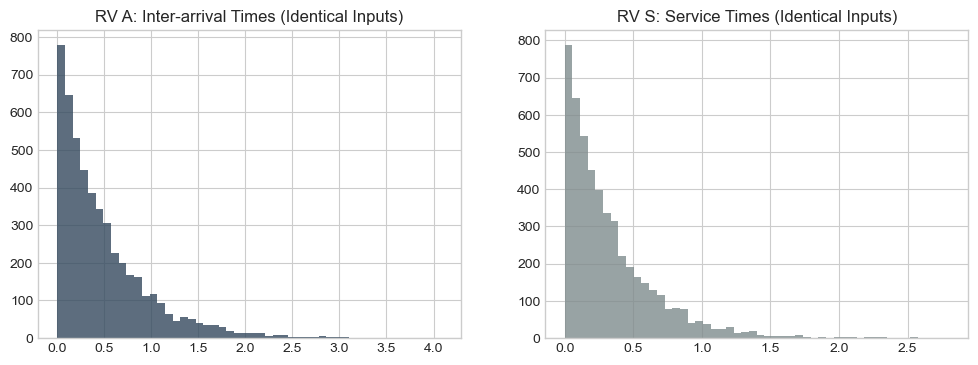

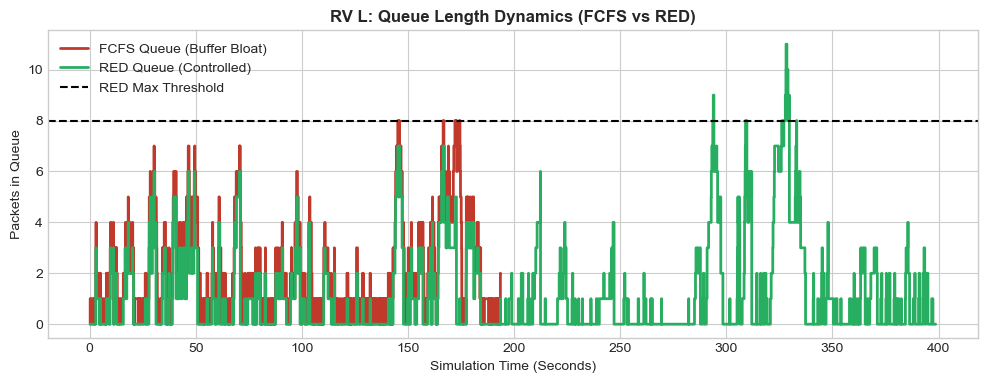

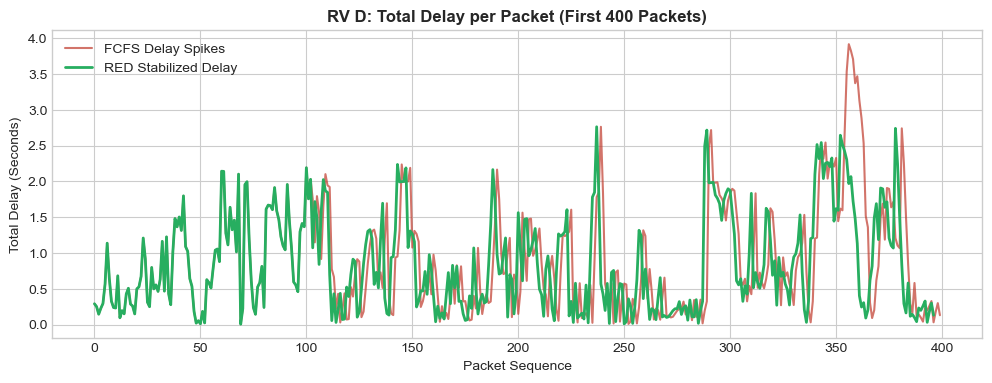

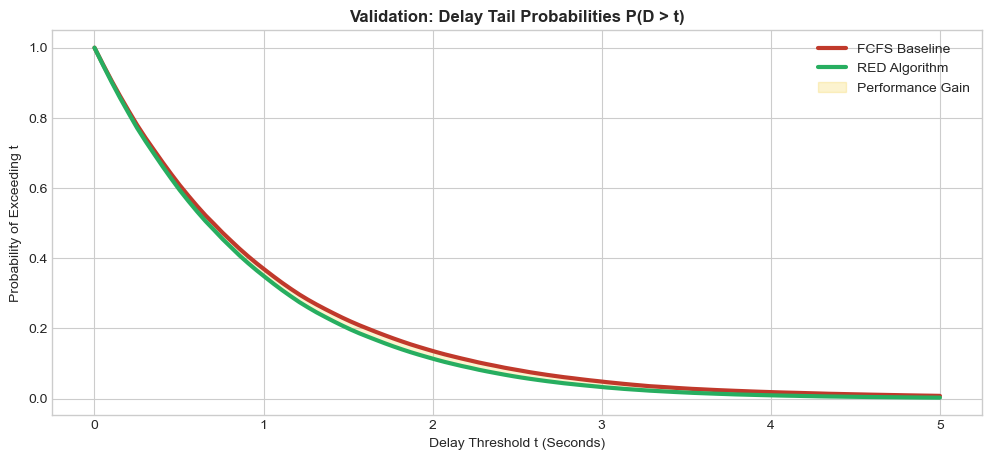

In [6]:
# --- OUTPUT METRICS & GRAPHS ---
plt.style.use('seaborn-v0_8-whitegrid')

print(f"--- METRICS ---")
print(f"FCFS Average Delay: {np.mean(D_fcfs):.4f}s")
print(f"RED Average Delay:  {np.mean(D_red_clean):.4f}s")
print(f"RED Packet Drop Rate: {drop_rate:.2f}%")

# Graph 1: The Inputs (Proving fairness)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(A[:5000], bins=50, color='#34495e', alpha=0.8)
axes[0].set_title('RV A: Inter-arrival Times (Identical Inputs)')
axes[1].hist(S[:5000], bins=50, color='#7f8c8d', alpha=0.8)
axes[1].set_title('RV S: Service Times (Identical Inputs)')
plt.show()

# Graph 2: Queue Length Comparison (RV L)
plt.figure(figsize=(12, 4))
plt.step(time_fcfs[:800], L_fcfs_hist[:800], label='FCFS Queue (Buffer Bloat)', color='#c0392b', linewidth=2)
plt.step(time_red[:800], L_red_hist[:800], label='RED Queue (Controlled)', color='#27ae60', linewidth=2)
plt.axhline(y=max_th, color='black', linestyle='--', label='RED Max Threshold')
plt.title('RV L: Queue Length Dynamics (FCFS vs RED)', fontweight='bold')
plt.xlabel('Simulation Time (Seconds)')
plt.ylabel('Packets in Queue')
plt.legend()
plt.show()

# Graph 3: Total Delay Spikes (RV D)
plt.figure(figsize=(12, 4))
plt.plot(range(400), D_fcfs[:400], label='FCFS Delay Spikes', color='#c0392b', alpha=0.7)
valid_red = [d for d in D_red[:400] if d is not None]
plt.plot(range(len(valid_red)), valid_red, label='RED Stabilized Delay', color='#27ae60', linewidth=2)
plt.title('RV D: Total Delay per Packet (First 400 Packets)', fontweight='bold')
plt.xlabel('Packet Sequence')
plt.ylabel('Total Delay (Seconds)')
plt.legend()
plt.show()

# Graph 4: Tail Probabilities
plt.figure(figsize=(12, 5))
t_vals = np.linspace(0, 5, 100)
plt.plot(t_vals, [np.sum(D_fcfs > t) / N for t in t_vals], label='FCFS Baseline', color='#c0392b', linewidth=3)
plt.plot(t_vals, [np.sum(D_red_clean > t) / len(D_red_clean) for t in t_vals], label='RED Algorithm', color='#27ae60', linewidth=3)
plt.fill_between(t_vals, [np.sum(D_fcfs > t)/N for t in t_vals], [np.sum(D_red_clean > t)/len(D_red_clean) for t in t_vals], color='#f1c40f', alpha=0.2, label='Performance Gain')
plt.title('Validation: Delay Tail Probabilities P(D > t)', fontweight='bold')
plt.xlabel('Delay Threshold t (Seconds)')
plt.ylabel('Probability of Exceeding t')
plt.legend()
plt.show()